# Combine Prophet and XGBoost for Time Series Forecasting

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder


In [4]:
df = pd.read_csv(r"C:\Users\Admin\Documents\Projects\Combine Prophet and XGBoost for Time Series Forecasting\PJME_hourly.csv", 
                 encoding='utf-8', parse_dates=['Datetime'], index_col='Datetime')

df = df[['PJME_MW']].rename(columns={'PJME_MW': 'y'})
df.head(3)


,y
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0


In [6]:
#Sintetik data (internet olmadan test üçün)
np.random.seed(42)
periods = 24 * 365 * 3   # 3 illik saatlıq data
dates = pd.date_range('2020-01-01', periods=periods, freq='h')

t = np.arange(periods)
trend      = 30000 + t * 0.05
yearly     = 8000  * np.sin(2 * np.pi * t / (24 * 365))
weekly     = 2000  * np.sin(2 * np.pi * t / (24 * 7))
daily      = 3000  * np.sin(2 * np.pi * t / 24)
noise      = np.random.normal(0, 500, periods) #overfitting olmasin

## Future Engineering

In [13]:
# Xarici dəyişənlər future engineering
temperature   = 15 + 10 * np.sin(2 * np.pi * t / (24 * 365)) + np.random.normal(0, 3, periods)
is_promotion  = (np.random.rand(periods) > 0.95).astype(int)
is_holiday    = ((dates.month == 12) & (dates.day.isin([25, 26]))).astype(int)

# Promo zamanı +10% artım
promo_effect = is_promotion * 3000
y_values     = trend + yearly + weekly + daily + promo_effect + noise

In [17]:
df = pd.DataFrame({
    'ds':          dates,
    'y':           y_values,
    'temperature': temperature,
    'is_promotion':is_promotion,
    'is_holiday':  is_holiday
})

df.shape
print(f'{df["ds"].min().date()} → {df["ds"].max().date()}')


2020-01-01 → 2022-12-30


In [19]:
#  Xüsusiyyətlər əlavə edirem XGBoost a
df['hour']       = df['ds'].dt.hour
df['dayofweek']  = df['ds'].dt.dayofweek
df['month']      = df['ds'].dt.month
df['quarter']    = df['ds'].dt.quarter
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

# Lag xüsusiyyətləri
df = df.sort_values('ds').reset_index(drop=True)
df['lag_24']  = df['y'].shift(24)    # bir gün əvvəl
df['lag_168'] = df['y'].shift(168)   # bir həftə əvvəl
df['roll_24'] = df['y'].shift(1).rolling(24).mean()   # 24 saatlıq ortalama

print(' Xüsusiyyətlər' , [c for c in df.columns if c not in ['ds','y']])
df.head()

 Xüsusiyyətlər ['temperature', 'is_promotion', 'is_holiday', 'hour', 'dayofweek', 'month', 'quarter', 'is_weekend', 'lag_24', 'lag_168', 'roll_24']


,ds,y,temperature,is_promotion,is_holiday,hour,dayofweek,month,quarter,is_weekend,lag_24,lag_168,roll_24
0,2020-01-01 00:00:00,30248.357077,17.008335,0,0,0,2,1,1,0,NaN,NaN,NaN
1,2020-01-01 01:00:00,30787.895442,20.164034,0,0,1,2,1,1,0,NaN,NaN,NaN
2,2020-01-01 02:00:00,31984.880590,11.252710,0,0,2,2,1,1,0,NaN,NaN,NaN
3,2020-01-01 03:00:00,33124.128417,16.809379,0,0,3,2,1,1,0,NaN,NaN,NaN
4,2020-01-01 04:00:00,32802.236300,10.428985,0,0,4,2,1,1,0,NaN,NaN,NaN


## Data Training

 Train: 25,776    Test: 336 


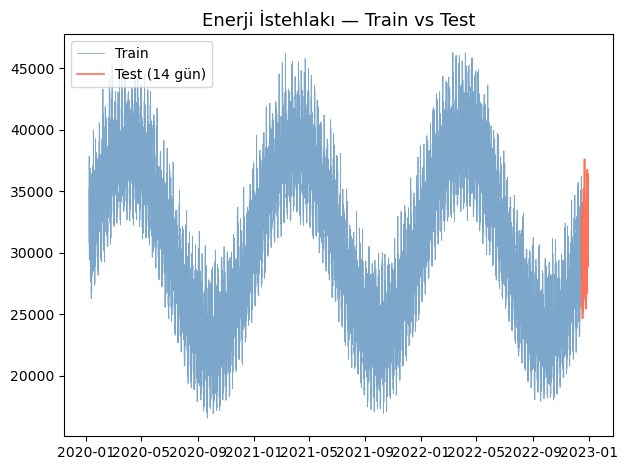

In [22]:
# Train / Test split
# Son 14 gün = test (tapşırıq tələbi)
FORECAST_HORIZON = 14 * 24   # 14 gün × 24 saat
#kesib ayiririq
train = df.iloc[:-FORECAST_HORIZON].copy()
test  = df.iloc[-FORECAST_HORIZON:].copy()

# Lag-ları olan satırları sil (NaN)
train = train.dropna()

print(f' Train: {len(train):,}    Test: {len(test):,} ')

# Vizual
fig, ax = plt.subplots()
ax.plot(train['ds'], train['y'], color='steelblue', alpha=0.7, label='Train', linewidth=0.6)
ax.plot(test['ds'],  test['y'],  color='tomato',    alpha=0.9, label='Test (14 gün)', linewidth=1.2)
ax.set_title('Enerji İstehlakı — Train vs Test', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## Prophet Model

In [27]:
# Prophet üçün data hazırlığı
prophet_train = train[['ds', 'y', 'temperature', 'is_promotion', 'is_holiday']].copy()
prophet_test  = test[['ds',  'y', 'temperature', 'is_promotion', 'is_holiday']].copy()

#  Model qur
model_prophet = Prophet(
    yearly_seasonality  = True,
    weekly_seasonality  = True,
    daily_seasonality   = True,
    seasonality_mode    = 'additive',
    changepoint_prior_scale = 0.05   # trend çevikliyini idarə eliyir
)

''' Xarici regresorlar əlavə edirik.Prophet indi həm trendi, həm mövsümiliyi,n/
həm də temperatur və promonun linear təsirlərini öyrənir'''
#model_prophet.add_regressor('temperature')
#model_prophet.add_regressor('is_promotion')
#model_prophet.add_regressor('is_holiday')
'''bunlari cixardim ki overfittingin ve ya cox oyrenmenin qarsisin alim n/
cunki xgboosta oyrenecek ya da duzeldecek nese qalmirdi'''
# Modeli öyrət
model_prophet.fit(prophet_train)


21:51:37 - cmdstanpy - INFO - Chain [1] start processing
21:51:45 - cmdstanpy - INFO - Chain [1] done processing


In [29]:
# Proqnoz al 
prophet_forecast = model_prophet.predict(prophet_test)

# Train üçün də predict lazımdır (residual hesablamaq üçün) XGBoost a verek
prophet_train_pred = model_prophet.predict(prophet_train)

# Residualları hesabla
train = train.copy()
train['prophet_pred'] = prophet_train_pred['yhat'].values
train['residual']     = train['y'] - train['prophet_pred']

test  = test.copy()
test['prophet_pred']  = prophet_forecast['yhat'].values
test['residual']      = test['y'] - test['prophet_pred']

#  Metrikler
def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

prophet_mape = mape(test['y'].values, test['prophet_pred'].values)
prophet_mae  = mean_absolute_error(test['y'], test['prophet_pred'])

print(f'Prophet Baseline  MAPE: {prophet_mape:.2f}%  |  MAE: {prophet_mae:,.0f}')

Prophet Baseline  MAPE: 1.74%  |  MAE: 534


In [31]:
# Train proqnozları üçün MAPE hesablayaq gorek overfiting deyil
train_mape = mape(train['y'].values, train['prophet_pred'].values)
train_mae = mean_absolute_error(train['y'], train['prophet_pred'])


print(f" TRAIN  {train_mape:.2f}% | MAE: {train_mae:,.0f}")
print(f" TEST  {prophet_mape:.2f}% | MAE: {prophet_mae:,.0f}")
#Deyil.Əgər model overfitting olsaydı, Train xətası çox kiçik olardi
#Test xətası isə ondan bir neçə dəfə böyük olardi

 TRAIN  1.82% | MAE: 548
 TEST  1.74% | MAE: 534


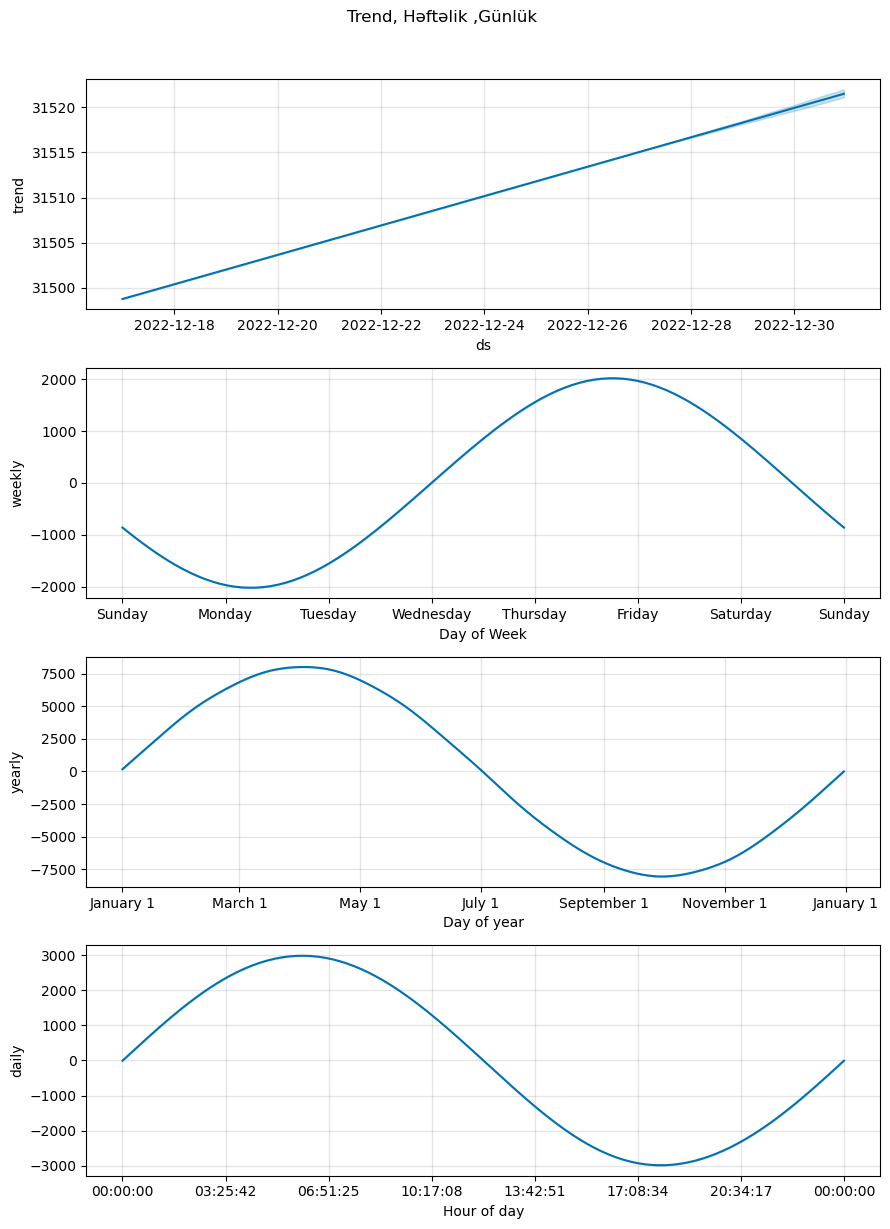

In [33]:
#Prophet komponentləri
fig = model_prophet.plot_components(prophet_forecast)
plt.suptitle('Trend, Həftəlik ,Günlük ', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

In [35]:
FEATURE_COLS = [
    'hour', 'dayofweek', 'month', 'quarter', 'is_weekend',
    'temperature', 'is_promotion', 'is_holiday',
    'lag_24', 'lag_168', 'roll_24'
]

X_train = train[FEATURE_COLS].fillna(0)
y_train = train['residual']

X_test  = test[FEATURE_COLS].fillna(0)
y_test  = test['residual']



## XGBoost Model

In [38]:


# XGBoost modeli
xgb_model = xgb.XGBRegressor(
    n_estimators       = 500,
    learning_rate      = 0.1,
    max_depth          = 3, #sondaki Auto Ml den goturerek deyimki n\
    # 3 derinlik bes edirki overfit olmasin
    subsample          = 0.9,
    colsample_bytree   = 0.9, #daha stabil olsun deye cetinlesdirici regularization etdim n\
    # amma datanin hamsin verdimki daha cox agac versin
    random_state       = 42,
    n_jobs             = -1,
    early_stopping_rounds = 50, #noise lari ezberlemesin overfittingin qarsisin alsin deye 
    #birazda cox verdim cunki prophetin deqiqliyi cox yuksek idi
    eval_metric        = 'mae'
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print(f' Ağac sayı {xgb_model.best_iteration}')

 Ağac sayı 33


## Future Importance

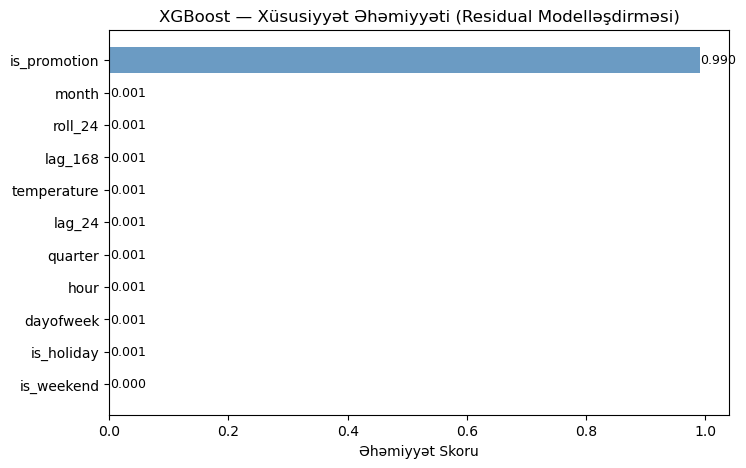

In [41]:
# XGBoost Feature Importance baxaq
importance = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS)
importance = importance.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(importance.index, importance.values, color='steelblue', alpha=0.8)

ax.set_title('XGBoost — Xüsusiyyət Əhəmiyyəti (Residual Modelləşdirməsi)', fontsize=12)
ax.set_xlabel('Əhəmiyyət Skoru')

for bar, val in zip(bars, importance.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)



plt.show()


is_promotion xüsusiyyətinin 0.991 (yəni 99.1%) Feature Importance balı alması o deməkdir ki,
XGBoost un qurduğu o 33 ağac demək olar ki, yalnız promosyonların yaratdığı səhvləri düzəltməyə köklənib

## Residual Prediction

In [45]:
# Residual proqnozu qururam
test['xgb_residual_pred'] = xgb_model.predict(X_test)

#  Hibrid proqnoz 
test['hybrid_pred'] = test['prophet_pred'] + test['xgb_residual_pred']

# Metriklər 
hybrid_mape = mape(test['y'].values, test['hybrid_pred'].values)
hybrid_mae  = mean_absolute_error(test['y'], test['hybrid_pred'])

improvement_mape = prophet_mape - hybrid_mape 
'''bu hibrid modelin tək modelə (baseline) nisbətən xətanı 
nə qədər azaltdığını göstərən faizdir.'''


print(f'  Prophet Baseline: {prophet_mape:.2f}%   MAE: {prophet_mae:,.0f}')
print(f'  Hybrid : {hybrid_mape:.2f}%   MAE: {hybrid_mae:,.0f}')
print(f'  Ferq: -{improvement_mape:.2f}%')

  Prophet Baseline: 1.74%   MAE: 534
  Hybrid : 1.37%   MAE: 412
  Ferq: -0.38%


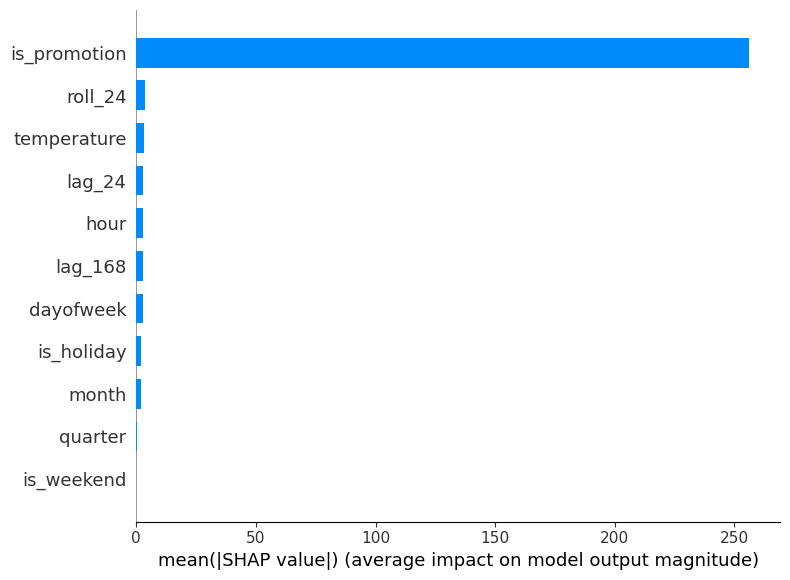

In [47]:
#Shap analizi
import shap
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
    
shap.summary_plot(shap_values, X_test, plot_type='bar')

## Auto ML Parametres

In [50]:
from sklearn.model_selection import RandomizedSearchCV

# Bu hissə parametrləri avtomatik yoxlayır (AutoML məntiqi)
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 500, 1000]
}

auto_xgb = RandomizedSearchCV(xgb.XGBRegressor(), param_grid, n_iter=5, cv=3)
auto_xgb.fit(X_train, y_train)

print(f"AutoML tərəfindən tapılan ən yaxşı parametrlər: {auto_xgb.best_params_}")

AutoML tərəfindən tapılan ən yaxşı parametrlər: {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01}
